In [1]:
import os

current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    os.chdir('..')
    print("Direktori aktif disesuaikan ke root proyek:", os.getcwd())
    

Direktori aktif disesuaikan ke root proyek: d:\pokemon-tcg-classification


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Cropping2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
# Konfigurasi Direktori
TRAIN_DIR = os.path.join('data', 'processed', 'train')
VAL_DIR = os.path.join('data', 'processed', 'val')
TEST_DIR = os.path.join('data', 'processed', 'test')

IMG_HEIGHT = 588
IMG_WIDTH = 420
BATCH_SIZE = 16 
NUM_CLASSES = 10

print("Menyiapkan Data Generator...")
# Menggunakan rescale 1./255 standar untuk CNN non-pretrained
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))


Menyiapkan Data Generator...
Found 1605 images belonging to 10 classes.
Found 340 images belonging to 10 classes.
Found 355 images belonging to 10 classes.


In [4]:
print("Membangun Arsitektur CNN Baseline (Micro-RoI)...")

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Pemotongan ke kuadran kiri bawah (sama dengan MobileNetV2)
top_crop = int(IMG_HEIGHT * 0.85)
bottom_crop = 0
left_crop = 0
right_crop = int(IMG_WIDTH * 0.70)

x = Cropping2D(cropping=((top_crop, bottom_crop), (left_crop, right_crop)), name='micro_roi_cropping')(inputs)

# Blok Konvolusi 1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

# Blok Konvolusi 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

# Blok Konvolusi 3
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = BatchNormalization()(x)

# Flatten & Klasifikasi
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()


Membangun Arsitektur CNN Baseline (Micro-RoI)...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 588, 420, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ micro_roi_cropping (Cropping2D) │ (None, 89, 126, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 89, 126, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 44, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 44, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 11, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21120)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,703,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,798,922 (10.68 MB)

 Trainable params: 2,798,474 (10.68 MB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
print("\n=== Memulai Pelatihan Baseline CNN ===")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    train_generator, 
    epochs=40, # Batas maksimal, akan berhenti otomatis jika sudah optimal
    validation_data=val_generator, 
    callbacks=[early_stop, reduce_lr], 
    class_weight=class_weight_dict
)



=== Memulai Pelatihan Baseline CNN ===
Epoch 1/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.2031 - loss: 3.0606 - val_accuracy: 0.1265 - val_loss: 3.8189 - learning_rate: 0.0010
Epoch 2/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 45s 445ms/step - accuracy: 0.2436 - loss: 2.0914 - val_accuracy: 0.1029 - val_loss: 4.6729 - learning_rate: 0.0010
Epoch 3/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 390ms/step - accuracy: 0.2474 - loss: 2.0256 - val_accuracy: 0.2382 - val_loss: 2.7289 - learning_rate: 0.0010
Epoch 4/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 41s 402ms/step - accuracy: 0.2511 - loss: 1.9834 - val_accuracy: 0.3529 - val_loss: 1.9939 - learning_rate: 0.0010
Epoch 5/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 40s 397ms/step - accuracy: 0.2779 - loss: 1.9543 - val_accuracy: 0.4912 - val_loss: 1.8275 - learning_rate: 0.0010
Epoch 6/40
101/101 ━━━━━━━━━━━━━━━━━━━━ 39s 388ms/step - accuracy: 0.2822 - loss: 1.9540 - val_accuracy: 0.4206 - val_loss: 1.7880 - learning_rate: 0.0010
Epoch 7/40
101/101 ━━━━━━━━━━━━━


Mengevaluasi model pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 378ms/step - accuracy: 0.4732 - loss: 1.5681
Akurasi Baseline pada Test Set: 47.32%

23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step


d:\pokemon-tcg-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\pokemon-tcg-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\pokemon-tcg-classification\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

                       precision    recall  f1-score   support

                  151       1.00      1.00      1.00        32
      destined-rivals       0.00      0.00      0.00        38
       evolving-skies       0.97      1.00      0.99        36
     journey-together       1.00      1.00      1.00        29
          lost-origin       1.00      1.00      1.00        38
       paldea-evolved       0.00      0.00      0.00        43
        paldean-fates       0.00      0.00      0.00        38
 prismatic-evolutions       0.00      0.00      0.00        28
scarlet-violet-promos       0.15      0.97      0.26        34
       surging-sparks       0.00      0.00      0.00        39

             accuracy                           0.47       355
            macro avg       0.41      0.50      0.42       355
         weighted avg       0.39      0.47      0.40       355



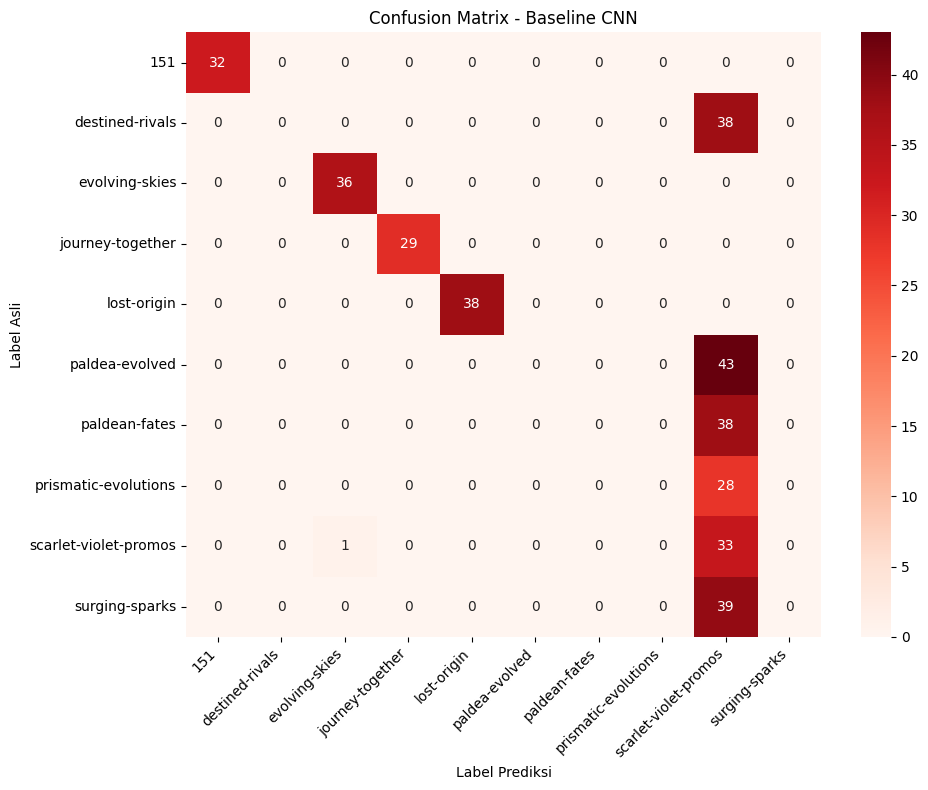

In [6]:
# Evaluasi Test Set
print("\nMengevaluasi model pada Test Set...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Akurasi Baseline pada Test Set: {test_acc * 100:.2f}%\n")

# Laporan & Confusion Matrix
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names) # Menggunakan warna merah untuk membedakan
plt.title('Confusion Matrix - Baseline CNN')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join('reports', 'confusion_matrix_baseline.png'))
plt.show()


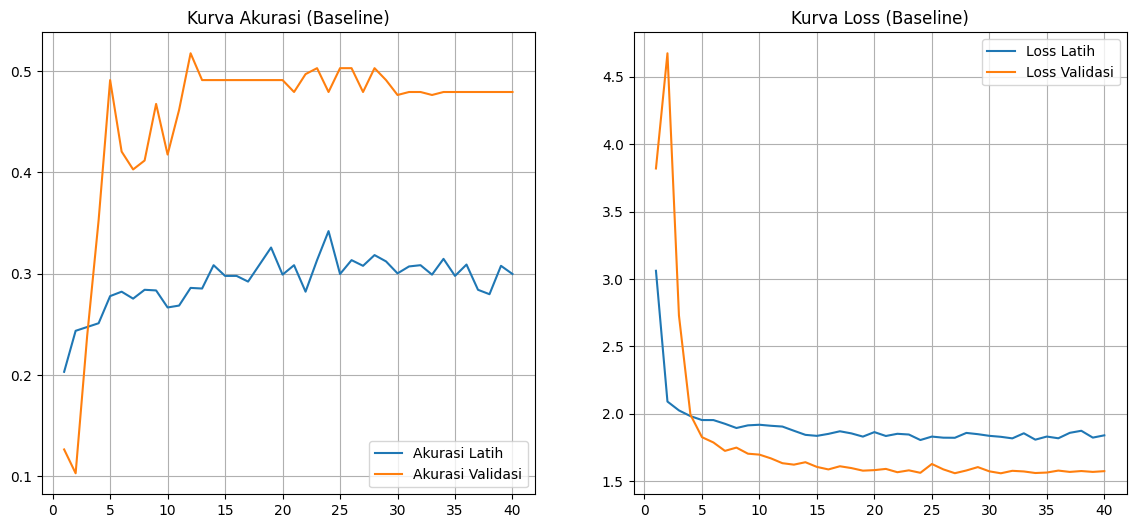

In [7]:
# Learning Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Latih')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
plt.title('Kurva Akurasi (Baseline)')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Latih')
plt.plot(epochs_range, val_loss, label='Loss Validasi')
plt.title('Kurva Loss (Baseline)')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig(os.path.join('reports', 'learning_curves_baseline.png'))
plt.show()

# Simpan Model (Opsional, sekadar untuk dokumentasi)
model.save(os.path.join('models', 'cnn_baseline.keras'))
